# Training The Model

## 1. Settin Up Path for CSV FIle and GDrive

In [1]:
import os
import pandas as pd

#CSV path of TOday's  words DF_1_to_25
CSV_PATH = r"G:\My Drive\Cleaned_Csv_Files\few_10.csv"

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    
    # Extract unique words (glosses) into a clean list
    new_words = df['gloss'].unique().tolist()
    
    print(f"Successfully loaded {len(new_words)} unique words for today's training.")
    print(f"Target Words: {new_words}")
    
    # Quick sanity check
    if len(new_words) != 25:
        print(f"⚠️ Heads up: Expected 25 words, but found {len(new_words)}.")
else:
    print(f"ERROR: Could not find the CSV file at {CSV_PATH}. Double-check the path!")

Successfully loaded 10 unique words for today's training.
Target Words: ['accident', 'africa', 'all', 'apple', 'basketball', 'bed', 'before', 'bird', 'birthday', 'black']
⚠️ Heads up: Expected 25 words, but found 10.


## 2. To Set up path For ASL_Videos, Aug_Data

In [2]:
import numpy as np
import pickle
import os


BASE_PATH = 'G:/My Drive/' # Suggested root folder
BASE_PATH2 = r'C:\Users\Uma_Manikanta\3D Objects\asl-translator\datasets'
DATA_PATH = os.path.join(BASE_PATH, 'ASL_Keypoints_Data_10')
AUG_DATA_PATH = os.path.join(BASE_PATH2, 'ASL_Augmented_Data_10')
LABEL_MAP_PATH = os.path.join(BASE_PATH, 'actions.pkl')

# Create folder if it don't exist
os.makedirs(AUG_DATA_PATH, exist_ok=True)

# 2. Load or Initialize the Label Map (The "Master List" of words)
if os.path.exists(LABEL_MAP_PATH):
    with open(LABEL_MAP_PATH, 'rb') as f:
        actions_list = list(pickle.load(f))
    print(f"Loaded existing Label Map with {len(actions_list)} words.")
else:
    actions_list = []
    print("No existing Label Map found. Starting fresh.")

# 3. Add TODAY'S new words to the Master List if they aren't already there
# 'new_words' comes from the previous cell (your CSV)
added_count = 0
for word in new_words:
    if word not in actions_list:
        actions_list.append(word)
        added_count += 1

# 4. Save the updated Master List back to your Drive
actions = np.array(actions_list)
with open(LABEL_MAP_PATH, 'wb') as f:
    pickle.dump(actions, f)

# 5. Create the mapping dictionary for the model
label_map = {label: num for num, label in enumerate(actions)}

print(f"Update complete. Added {added_count} new words.")
print(f"Total vocabulary size: {len(actions)}")

Loaded existing Label Map with 10 words.
Update complete. Added 0 new words.
Total vocabulary size: 10


# 3. To Augmenting the Data and Saving

In [3]:
import os
import numpy as np

# 1. Define the Augmentation Function tailored for daily updates
def apply_augmentation(source_path, target_path, words_to_augment, n_generated=5):
    print("Starting augmentation process...")
    
    for action in words_to_augment:
        action_path = os.path.join(source_path, action)
        save_action_path = os.path.join(target_path, action)
        
        # Check if raw data actually exists for this word
        if not os.path.exists(action_path):
            print(f"⚠️ Warning: No raw data found for '{action}'. Skipping.")
            continue
            
        os.makedirs(save_action_path, exist_ok=True)
        
        # CRITICAL FIX: Skip if we already augmented this word to save time
        if len(os.listdir(save_action_path)) > 0:
            print(f"⏩ Skipping '{action}': Already augmented.")
            continue

        video_files = [f for f in os.listdir(action_path) if f.endswith('.npy')]
        print(f"⚙️ Augmenting word: '{action}' ({len(video_files)} original files)...")

        for video_file in video_files:
            # Load original sequence
            res = np.load(os.path.join(action_path, video_file))
            
            # Save original as variation 0
            np.save(os.path.join(save_action_path, f"orig_{video_file}"), res)

            # Generate synthetic variations
            for i in range(n_generated):
                # Gaussian Noise (Simulates camera grain/hand jitter)
                noise = np.random.normal(0, 0.005, res.shape)
                augmented_res = res + noise

                # Spatial Shift (Simulates user moving slightly in frame)
                shift = np.random.uniform(-0.02, 0.02)
                augmented_res = augmented_res + shift

                # Save the augmented version
                np.save(os.path.join(save_action_path, f"aug_{i}_{video_file}"), augmented_res)

# 2. Execute ONLY for today's new words
apply_augmentation(DATA_PATH, AUG_DATA_PATH, new_words)
print("\n✅ Augmentation complete for today's batch!")

Starting augmentation process...
⚙️ Augmenting word: 'accident' (4 original files)...
⚙️ Augmenting word: 'africa' (5 original files)...
⚙️ Augmenting word: 'all' (5 original files)...
⚙️ Augmenting word: 'apple' (5 original files)...
⚙️ Augmenting word: 'basketball' (4 original files)...
⚙️ Augmenting word: 'bed' (4 original files)...
⚙️ Augmenting word: 'before' (4 original files)...
⚙️ Augmenting word: 'bird' (4 original files)...
⚙️ Augmenting word: 'birthday' (4 original files)...
⚙️ Augmenting word: 'black' (4 original files)...

✅ Augmentation complete for today's batch!


## 4. Train Test Split

In [4]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# 1. We already have 'actions' and 'label_map' from Cell 2 in memory.
# Let's double-check the label map just to be sure.
print(f"Total classes to load: {len(label_map)}")

# 2. Load sequences (X) and labels (y)
sequences, labels = [], []

# We iterate through ALL words in our Master List, not just 'new_words'
print("Loading all augmented data into memory... (This might take a moment as your dataset grows)")

for action in actions: # 'actions' is our master list of all words
    action_folder = os.path.join(AUG_DATA_PATH, action)
    
    # Skip if the folder doesn't exist yet for some reason
    if not os.path.exists(action_folder):
        continue
        
    files = [f for f in os.listdir(action_folder) if f.endswith('.npy')]

    for file in files:
        res = np.load(os.path.join(action_folder, file))
        sequences.append(res)
        labels.append(label_map[action])

# 3. Convert to Numpy arrays
X = np.array(sequences)
# One-hot encode the labels using the TOTAL number of actions we know about
y = to_categorical(labels, num_classes=len(actions)).astype(int)

# 4. Split the data
# Using 10% for testing. If you want a stricter evaluation for your 95%+ goal, 
# you could bump this to 0.20 (20%), but 10% is fine while building up data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

print(f"\n✅ Data successfully loaded and split!")
print(f"X_train shape: {X_train.shape}") # Should be (Samples, 30 frames, 1662 keypoints)
print(f"y_train shape: {y_train.shape}") # Should be (Samples, Number of Words)

Total classes to load: 10
Loading all augmented data into memory... (This might take a moment as your dataset grows)

✅ Data successfully loaded and split!
X_train shape: (232, 25, 351)
y_train shape: (232, 10)


## 5. Creating a New model with previous model (if exists

In [5]:
import os
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Define where the model lives locally
global BASE_PATH
MODEL_SAVE_PATH = os.path.join(BASE_PATH, 'asl_model_v1.keras')

# Total number of words we are training on today
num_classes = len(actions)

# 2. Check if we are updating an old model or starting fresh
if os.path.exists(MODEL_SAVE_PATH):
    print(f"🧠 Loading existing model from: {MODEL_SAVE_PATH}")
    old_model = load_model(MODEL_SAVE_PATH)
    
    # Perform "Surgery" to swap the final prediction layer
    # We grab the output from the second-to-last layer (the Dense layer with 32 units)
    second_to_last_layer = old_model.layers[-2].output
    
    # Create a brand new final layer with today's number of classes
    # We give it a unique name so Keras doesn't get confused by the old layer's weights
    new_output = Dense(num_classes, activation='softmax', name=f'predictions_{num_classes}')(second_to_last_layer)
    
    # Stitch the old body to the new head
    model = Model(inputs=old_model.input, outputs=new_output)
    print(f"✅ Successfully updated the output layer to predict {num_classes} words.")

else:
    print("🌱 No existing model found. Building a new model from scratch...")
    model = Sequential()
    
    # Input shape: 30 frames per video, 1662 keypoints per frame
    model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(25, 351)))
    model.add(Dropout(0.2)) 
    
    model.add(LSTM(128, return_sequences=True, activation='relu'))
    model.add(Dropout(0.2))
    
    model.add(LSTM(64, return_sequences=False, activation='relu'))
    model.add(Dropout(0.2))
    
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    
    # Final layer matches the number of words perfectly
    model.add(Dense(num_classes, activation='softmax'))

# 3. Compile the model
# We must recompile even if we loaded an old model because we changed the architecture
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

# Print the summary to verify the final Dense layer matches len(actions)
model.summary()

🌱 No existing model found. Building a new model from scratch...


C:\Users\Uma_Manikanta\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 25, 64)              │         106,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 25, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 25, 128)             │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 25, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 261,290 (1020.66 KB)

 Trainable params: 261,290 (1020.66 KB)

 Non-trainable params: 0 (0.00 B)

## 6. training the model

In [6]:
import os
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping

# 1. Set up Callbacks for monitoring and efficiency
log_dir = os.path.join('Logs')
os.makedirs(log_dir, exist_ok=True)
tb_callback = TensorBoard(log_dir=log_dir)

# Early stopping prevents overfitting. If the validation loss doesn't improve 
# for 20 epochs, it stops training and restores the best weights.
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True,
    verbose=1
)

# 2. Train the model
print("🚀 Starting training process...")
# We use a high number of epochs, but early_stopping will likely cut it off sooner
history = model.fit(
    X_train, 
    y_train, 
    validation_data=(X_test, y_test), # Using the test set as validation
    epochs=100, 
    callbacks=[tb_callback, early_stopping]
)
print("✅ Training complete!")

# 3. Save the model so we can load it tomorrow for the next 25 words
model.save(MODEL_SAVE_PATH)
print(f"💾 Model successfully saved to: {MODEL_SAVE_PATH}")

🚀 Starting training process...
Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - categorical_accuracy: 0.1293 - loss: 2.2142 - val_categorical_accuracy: 0.1923 - val_loss: 1.9810
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - categorical_accuracy: 0.2026 - loss: 2.0515 - val_categorical_accuracy: 0.2308 - val_loss: 1.8947
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - categorical_accuracy: 0.2500 - loss: 2.0009 - val_categorical_accuracy: 0.3077 - val_loss: 1.8346
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - categorical_accuracy: 0.2371 - loss: 2.0530 - val_categorical_accuracy: 0.3462 - val_loss: 1.7796
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - categorical_accuracy: 0.2931 - loss: 1.8894 - val_categorical_accuracy: 0.4615 - val_loss: 1.6118
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - categorical_accuracy: 0.3017 - loss: 1.9635 - val_categorical_accuracy: 0.2308 - val_loss: 2.0518
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - categorical_accu

## 7. Metrics

📂 Loading saved model from: G:/My Drive/asl_model_v1.keras...
✅ Model loaded successfully!
🧠 Generating predictions on the test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 848ms/step

📊 Overall Test Accuracy: 61.54%

📋 Classification Report:
              precision    recall  f1-score   support

    accident       1.00      1.00      1.00         3
      africa       0.50      0.20      0.29         5
         all       1.00      1.00      1.00         4
       apple       0.50      0.75      0.60         4
  basketball       1.00      0.33      0.50         3
         bed       0.00      0.00      0.00         0
      before       0.40      1.00      0.57         2
        bird       0.00      0.00      0.00         2
    birthday       0.50      1.00      0.67         1
       black       1.00      0.50      0.67         2

    accuracy                           0.62        26
   macro avg       0.59      0.58      0.53        26
weighted avg       0.68      0.62      0.60        26

🎨 Plotti

C:\Users\Uma_Manikanta\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Uma_Manikanta\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Uma_Manikanta\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn

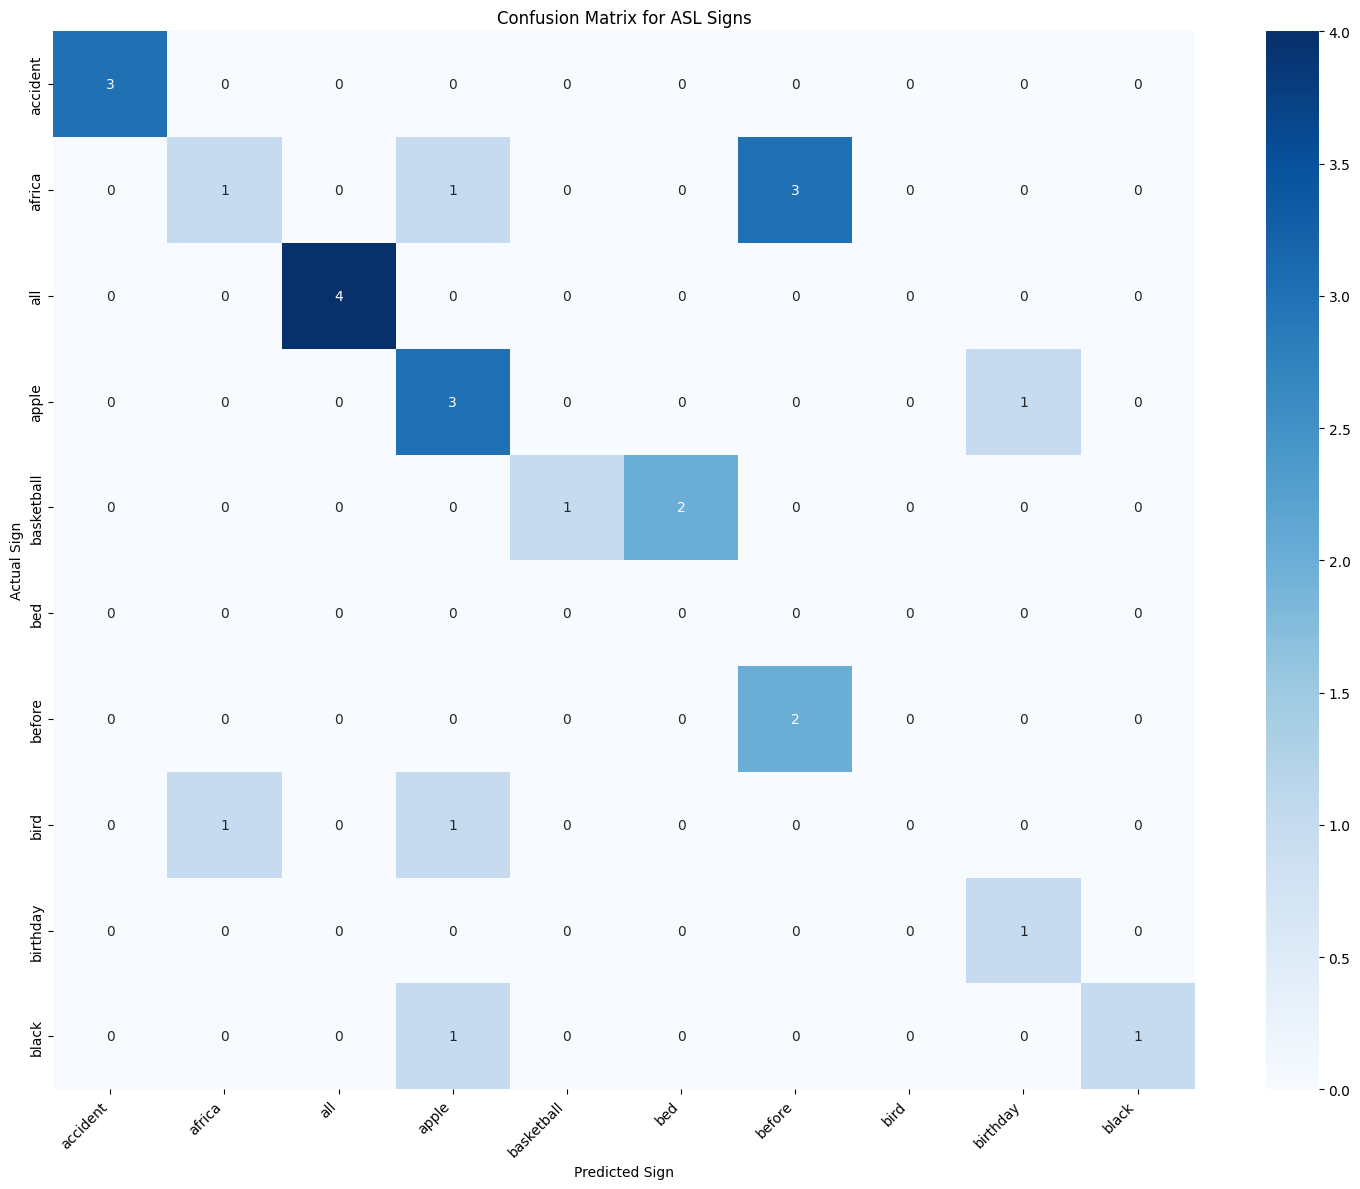

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Re-establish the path and load the saved model
BASE_PATH = 'G:/My Drive/' 
MODEL_SAVE_PATH = os.path.join(BASE_PATH, 'asl_model_v1.keras')

print(f"📂 Loading saved model from: {MODEL_SAVE_PATH}...")
model = load_model(MODEL_SAVE_PATH)
print("✅ Model loaded successfully!")

# 2. Get the model's predictions on the unseen test data
print("🧠 Generating predictions on the test set...")
y_pred = model.predict(X_test)

# 3. Convert predictions and true labels from one-hot encoding back to normal integers
y_true_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

# 4. Calculate and print the overall accuracy
accuracy = accuracy_score(y_true_labels, y_pred_labels)
print(f"\n📊 Overall Test Accuracy: {accuracy * 100:.2f}%\n")

# 5. Generate a detailed Classification Report
print("📋 Classification Report:")
print(classification_report(y_true_labels, y_pred_labels, target_names=actions))

# 6. Build and plot the visual Confusion Matrix
print("🎨 Plotting Confusion Matrix...")
cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(15, 12)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=actions, yticklabels=actions)

plt.title('Confusion Matrix for ASL Signs')
plt.xlabel('Predicted Sign')
plt.ylabel('Actual Sign')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Validation

In [8]:
# 1. Grab a sample from the test set
test_sample = X_test[0] # Take the first video in the test set
true_label = np.argmax(y_test[0])

# 2. Make a prediction
# We add np.expand_dims because the model expects a batch of videos
prediction = model.predict(np.expand_dims(test_sample, axis=0))

# 3. Compare the results
predicted_label = np.argmax(prediction)
confidence = np.max(prediction) * 100

print(f"True Word: {actions[true_label]}")
print(f"Predicted Word: {actions[predicted_label]}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
True Word: all
Predicted Word: all
Confidence: 100.00%
